In [42]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

In [44]:
low_folder = r"C:\Users\Vyshnav\Downloads\archive (5)\lol_dataset\our485\high"
high_folder = r"C:\Users\Vyshnav\Downloads\archive (5)\lol_dataset\our485\low"
img_height, img_width = 256, 256
batch_size = 8
epochs = 10

In [46]:
def compute_retinex_illumination(low_img, high_img):
    low_img = low_img.astype(np.float32) + 1e-5
    high_img = high_img.astype(np.float32) + 1e-5
    illumination_map = np.log(high_img) - np.log(low_img)
    # illumination_map = np.mean(illumination_map, axis=2, keepdims=True)
    return illumination_map

def load_and_preprocess_pair(low_path, high_path):
    low_img = cv2.imread(low_path, cv2.IMREAD_COLOR)
    high_img = cv2.imread(high_path, cv2.IMREAD_COLOR)

    if low_img is None or high_img is None:
        return None, None

    low_img = cv2.resize(low_img, (img_width, img_height))
    high_img = cv2.resize(high_img, (img_width, img_height))
    low_img = low_img / 255.0
    high_img = high_img / 255.0

    illumination_map = compute_retinex_illumination(low_img, high_img)
    illumination_map = cv2.normalize(illumination_map, None, 0, 1, cv2.NORM_MINMAX)

    return low_img, illumination_map

low_files = sorted([f for f in os.listdir(low_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
X, Y = [], []

for filename in low_files:
    low_path = os.path.join(low_folder, filename)
    high_path = os.path.join(high_folder, filename)
    if not os.path.exists(high_path):
        continue

    low_img, illum_map = load_and_preprocess_pair(low_path, high_path)
    if low_img is not None and illum_map is not None:
        X.append(low_img)
        Y.append(illum_map)

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.float32)

print(f"Loaded dataset: {X.shape} inputs, {Y.shape} illumination maps")

Loaded dataset: (485, 256, 256, 3) inputs, (485, 256, 256, 3) illumination maps


In [47]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

In [48]:
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = layers.Conv2DTranspose(512, (2,2), strides=(2,2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(3, (1,1), activation='sigmoid')(c9)

    model = models.Model(inputs, outputs)
    return model

model = build_unet((img_height, img_width, 3))
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 256, 256, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_57 (Conv2D)            │ (None, 256, 256, 64)      │           1,792 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_58 (Conv2D)            │ (None, 256, 256, 64)      │          36,928 │ conv2d_57[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_12              │ (None, 128, 128, 64)      │               0 │ conv2d_58[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_59 (Conv2D)            │ (None, 128, 128, 128)     │          73,856 │ max_pooling2d_12[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_60 (Conv2D)            │ (None, 128, 128, 128)     │         147,584 │ conv2d_59[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_13              │ (None, 64, 64, 128)       │               0 │ conv2d_60[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_61 (Conv2D)            │ (None, 64, 64, 256)       │         295,168 │ max_pooling2d_13[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_62 (Conv2D)            │ (None, 64, 64, 256)       │         590,080 │ conv2d_61[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_14              │ (None, 32, 32, 256)       │               0 │ conv2d_62[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_63 (Conv2D)            │ (None, 32, 32, 512)       │       1,180,160 │ max_pooling2d_14[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_64 (Conv2D)            │ (None, 32, 32, 512)       │       2,359,808 │ conv2d_63[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_15              │ (None, 16, 16, 512)       │               0 │ conv2d_64[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_65 (Conv2D)            │ (None, 16, 16, 1024)      │       4,719,616 │ max_pooling2d_15[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_66 (Conv2D)            │ (None, 16, 16, 1024)      │       9,438,208 │ conv2d_65[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 31,031,875 (118.38 MB)

 Trainable params: 31,031,875 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    batch_size=batch_size,
    epochs=epochs
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 545s 11s/step - loss: 0.0445 - mae: 0.1758 - val_loss: 0.0600 - val_mae: 0.2132
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 557s 11s/step - loss: 0.0389 - mae: 0.1698 - val_loss: 0.0581 - val_mae: 0.2109
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 565s 11s/step - loss: 0.0382 - mae: 0.1682 - val_loss: 0.0554 - val_mae: 0.2075
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 536s 11s/step - loss: 0.0380 - mae: 0.1677 - val_loss: 0.0548 - val_mae: 0.2063
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 532s 11s/step - loss: 0.0376 - mae: 0.1673 - val_loss: 0.0556 - val_mae: 0.2075
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 562s 11s/step - loss: 0.0376 - mae: 0.1672 - val_loss: 0.0562 - val_mae: 0.2084
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 533s 11s/step - loss: 0.0376 - mae: 0.1670 - val_loss: 0.0549 - val_mae: 0.2065
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 532s 11s/step - loss: 0.0374 - mae: 0.1668 - val_loss: 0.0565 - val_mae: 0.2089
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 535s 11s/step - lo

In [50]:
loss, mae = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss:.4f}, MAE: {mae:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 7s/step - loss: 0.0596 - mae: 0.2136
Test Loss: 0.0566, MAE: 0.2092


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step


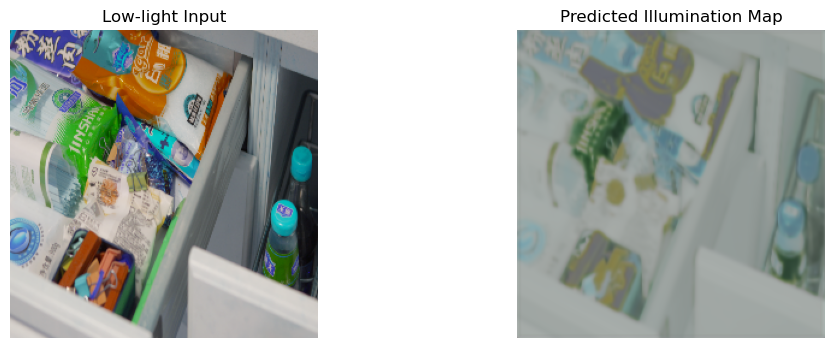

In [59]:
import matplotlib.pyplot as plt

idx = np.random.randint(0, len(X_test))
pred = model.predict(np.expand_dims(X_test[idx], axis=0))[0]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.title("Low-light Input")
plt.imshow(X_test[idx])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Illumination Map")
plt.imshow(pred.squeeze(), cmap='gray')
plt.axis("off")
plt.show()